# MgO Lattice Energy Exercise: Lennard-Jones vs. Born-Landé

In this exercise, you will study simplified models for the interaction energy in bulk MgO as a function of the Mg–O nearest-neighbour distance $r$.

The main goal is to understand how different analytical potential models describe the balance between **attractive** and **repulsive** interactions in an ionic crystal, and how well these models reproduce a literature-inspired reference energy curve.

You will work with two model families:

- **Model 1 (Lennard-Jones 12-6):**  
  $$
  U_{\mathrm{LJ}}(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right]
  $$

- **Model 2 (Born-Landé type):**  
  $$
  U_{\mathrm{BL}}(r)=-\frac{A}{r}+\frac{B}{r^n}
  $$

<a href="https://link.springer.com/chapter/10.1007/978-94-009-3981-3_7">Literature</a> for Model 2:

The exercise is structured so that you first explore the qualitative behaviour of these models, then fit them to a smooth MgO reference curve, and finally compare their physical plausibility and fit quality.

Units used throughout:

- $r$ in Angstrom
- $U$ in eV per ion pair

## Step 0 - Setup

Run this first for imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, curve_fit, brentq

## Step 1 - Model 1: Lennard-Jones 

The model equation is:

$$
U_{\mathrm{LJ}}(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right]
$$


### What you should do
1. Implement `U_lj(r, eps, sig)`.
2. Evaluate on a grid $r\in[1.45,3.85], numsteps=60$ using <a href="https://numpy.org/devdocs/reference/generated/numpy.linspace.html">np.linspace()</a>.
3. Plot the potential curve `U_lj` over `r`. Add axis labels and a fitting title.

In [2]:
eps_lj = 9.5
sig_lj = 1.95

In [3]:
def U_lj(r, eps, sig):
    return 4*eps * (np.pow(sig/r, 12) - np.pow(sig/r, 6))

In [18]:
r = np.linspace(1.45, 3.85, 60)
U_lj_curve = U_lj(r, eps_lj, sig_lj)

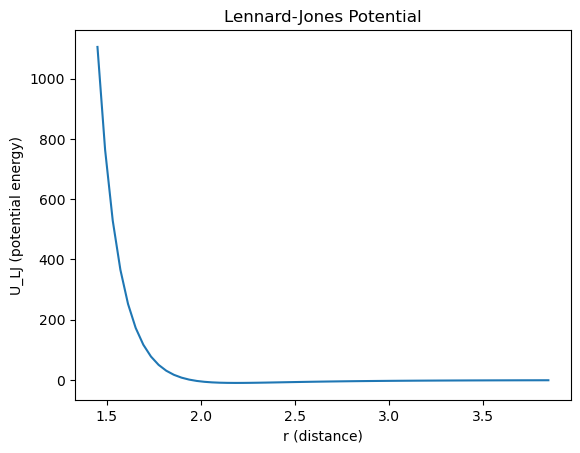

In [19]:
plt.plot(r, U_lj_curve)
plt.xlabel("r (distance)")
plt.ylabel("U_LJ (potential energy)")
plt.title("Lennard-Jones Potential")
plt.show()

In [20]:
# Assert block 1
assert U_lj_curve.shape == r.shape
assert np.all(np.isfinite(U_lj_curve))

## Step 2 - Latice Energy of Lennard-Jones 


### What you should do
1. Define the 2 Derivatives 

$$
\frac{dU_{\mathrm{LJ}}}{dr}=4\epsilon\left[-12\frac{\sigma^{12}}{r^{13}}+6\frac{\sigma^6}{r^7}\right]
$$

$$
\frac{d^2U_{\mathrm{LJ}}}{dr^2}=4\epsilon\left[156\frac{\sigma^{12}}{r^{14}}-42\frac{\sigma^6}{r^8}\right]
$$

2. Find $r_0$ by solving $dU_{\mathrm{LJ}}/dr=0$ using `brentq()` with the interval $r\in[1.45,3.85]$. Read the <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html">Documentation</a> to find out how to use this function.
3. Compute curvature $d^2U_{\mathrm{LJ}}/dr^2$ at that point.
4. Verify $d^2U/dr^2>0$ (stable lattice-energy minimum).
5. Plot the Leanard Jones Potential with the minimum as a point using <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html">ax.scatter()</a> to mark the minimum.

### Why this step matters
The derivative gives the force-balance condition of the effective pair potential. The second derivative confirms whether this stationary point is a stable crystal-like equilibrium in the model.

In [22]:
def dU_lj(r, eps, sig):
    return 4*eps * (-12 * np.pow(sig, 12)/np.pow(r, 13) + 6 * np.pow(sig, 6)/np.pow(r, 7))

def d2U_lj(r, eps, sig):
    return 4*eps * (156 * np.pow(sig, 12)/np.pow(r, 14) - 42 * np.pow(sig, 6)/np.pow(r, 8))

In [26]:
r0_lj_root = brentq(dU_lj, 1.45, 3.85, args=(eps_lj, sig_lj))
U0_lj_root = U_lj(r0_lj_root, eps_lj, sig_lj)
#for extrema in r0_lj_root:
#    second_deriv = brentq(d2U_lj, 1.45, 3.85)
#    print(second_deriv)

In [27]:
curv_lj_root = d2U_lj(r0_lj_root, eps_lj, sig_lj)

In [29]:
def check_stable(val):
    return val > 0

In [30]:
assert check_stable(curv_lj_root)

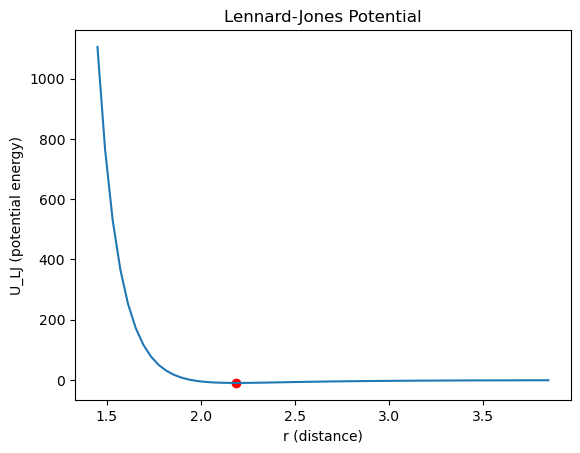

In [44]:
# 5 TODO: Plot U_lj_curve again with the minimum marked as a point.
plt.plot(r, U_lj_curve)
plt.scatter(r0_lj_root, U0_lj_root, marker="o", color="red")
plt.xlabel("r (distance)")
plt.ylabel("U_LJ (potential energy)")
plt.title("Lennard-Jones Potential")
plt.show()

In [45]:
# Optimizer cross-check
res_lj = minimize_scalar(lambda x: U_lj(x, eps_lj, sig_lj), bounds=(1.2, 4.0), method='bounded')
r0_lj_opt, U0_lj_opt = res_lj.x, res_lj.fun

print(f'LJ root method: r0={r0_lj_root:.5f}, U0={U0_lj_root:.5f}, d2U={curv_lj_root:.5f}')
print(f'LJ optimizer:   r0={r0_lj_opt:.5f}, U0={U0_lj_opt:.5f}')

LJ root method: r0=2.18880, U0=-9.50000, d2U=142.77217
LJ optimizer:   r0=2.18880, U0=-9.50000


In [46]:
# Assert block 2
assert 1.6 < r0_lj_root < 2.8
assert curv_lj_root > 0.0
assert abs(U0_lj_root - -9.50000) < 1
assert abs(r0_lj_root - 2.18880) < 0.1

## Step 3 - Model 2: Born-Landé type

Model equation:

$$
U_{\mathrm{BL}}(r)=-\frac{A}{r}+\frac{B}{r^n}
$$


### What you should do
1. Implement `U_bl`.
2. Compute and plot the potential curve with baseline parameters.

In [50]:
# SETUP
A_bl = 95.0
B_bl = 1600.0
n_bl = 9.0

In [48]:
def U_bl(r, A, B, n):
    return -A/r + B/np.pow(r, n)

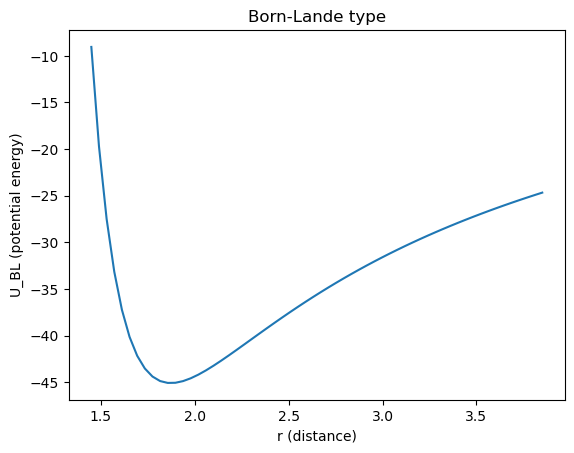

In [52]:
U_bl_curve = U_bl(r, A_bl, B_bl, n_bl)

plt.plot(r, U_bl_curve)
plt.xlabel("r (distance)")
plt.ylabel("U_BL (potential energy)")
plt.title("Born-Lande type")
plt.show()

In [53]:
# Assert block 3
assert U_bl_curve.shape == r.shape
assert np.all(np.isfinite(U_bl_curve))

## Step 4 - Equilibrium of Born-Landé via derivatives
Derivatives for equilibrium and stability:

$$
\frac{dU_{\mathrm{BL}}}{dr}=\frac{A}{r^2}-\frac{nB}{r^{n+1}},
\qquad
\frac{d^2U_{\mathrm{BL}}}{dr^2}=-\frac{2A}{r^3}+\frac{n(n+1)B}{r^{n+2}}.
$$

### What you should do
1. Define derivatives.
2. Solve $dU_{\mathrm{BL}}/dr=0$ for equilibrium distance.
3. Evaluate $d^2U_{\mathrm{BL}}/dr^2$ at the root.
4. Confirm stable minimum.
5. Plot `U_bl` with minimum Point using <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html">ax.scatter()</a>.

In [54]:
def dU_bl(r, A, B, n):
    return A/np.pow(r, 2) - (n*B)/np.pow(r, n+1)

def d2U_bl(r, A, B, n):
    return -(2*A)/np.pow(r, 3) + (n*(n+1)*B)/np.pow(r, n+2)

In [58]:
# 2 TODO: Use brentq() to find dU_bl/dr = 0. Store the minimum points r-value into a variable called r0_bl_root. Calculate the U_bl(r0_bl_root) value and store it into a variable called U0_bl_root
r0_bl_root = brentq(dU_bl, 1.45, 3.85, args=(A_bl, B_bl, n_bl))
U0_bl_root = U_bl(r0_bl_root, A_bl, B_bl, n_bl)

In [59]:
curv_bl_root = d2U_bl(r0_bl_root, A_bl, B_bl, n_bl)

In [ ]:
# 4 TODO: Use the check_stable(val) function we have already defined in Step 2 to check if this is a stable minimum. 
# (already present in the cell below?)

In [60]:
assert check_stable(curv_bl_root)

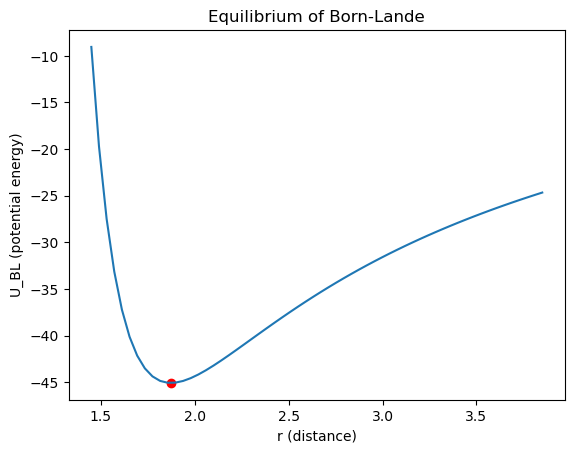

In [61]:
plt.plot(r, U_bl_curve)
plt.scatter(r0_bl_root, U0_bl_root, marker="o", color="red")
plt.xlabel("r (distance)")
plt.ylabel("U_BL (potential energy)")
plt.title("Equilibrium of Born-Lande")
plt.show()

In [62]:
res_bl = minimize_scalar(lambda x: U_bl(x, A_bl, B_bl, n_bl), bounds=(1.2, 4.0), method='bounded')
r0_bl_opt, U0_bl_opt = res_bl.x, res_bl.fun

print(f'BL root method: r0={r0_bl_root:.5f}, U0={U0_bl_root:.5f}, d2U={curv_bl_root:.5f}')
print(f'BL optimizer:   r0={r0_bl_opt:.5f}, U0={U0_bl_opt:.5f}')

BL root method: r0=1.87318, U0=-45.08076, d2U=115.63093
BL optimizer:   r0=1.87318, U0=-45.08076


In [63]:
# Assert block 4
assert 1.5 < r0_bl_root < 2.8
assert curv_bl_root > 0.0
assert abs(r0_bl_root - 1.87318) < 0.1
assert abs(U0_bl_root - (-45.08076)) < 0.1

## Step 5 - Baseline model-to-model comparison.

### What you should do
1. Overlay both baseline potentials. By calling <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html">ax.plot()</a> twice.

We will use this as a pre-fit benchmark.

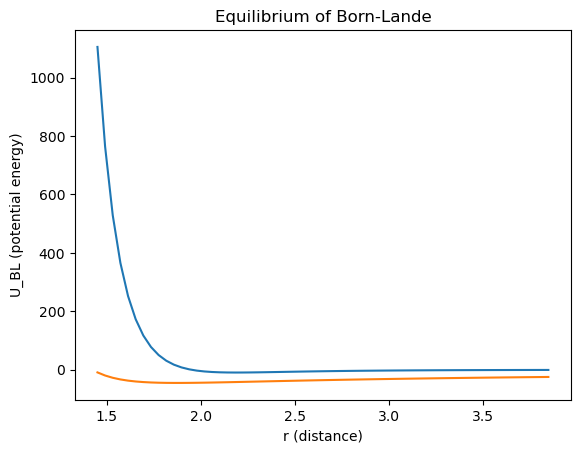

In [64]:
# 1 TODO: Overlay U_lj_curve and U_bl_curve in a single plot.
plt.plot(r, U_lj_curve)
plt.plot(r, U_bl_curve)
plt.xlabel("r (distance)")
plt.ylabel("U_BL (potential energy)")
plt.title("Equilibrium of Born-Lande")
plt.show()

In [65]:
print(f"{'Model':<18} {'r0 [A]':>10} {'U0 [eV]':>12} {'d2U(r0)':>12}")
print('-' * 56)
print(f"{'Lennard-Jones':<18} {r0_lj_root:10.5f} {U0_lj_root:12.5f} {curv_lj_root:12.5f}")
print(f"{'Born-Landé':<18} {r0_bl_root:10.5f} {U0_bl_root:12.5f} {curv_bl_root:12.5f}")

Model                  r0 [A]      U0 [eV]      d2U(r0)
--------------------------------------------------------
Lennard-Jones         2.18880     -9.50000    142.77217
Born-Landé            1.87318    -45.08076    115.63093


## Step 6 - Provided reference energy curve of MgO

In this step we introduce a smooth reference energy curve for bulk MgO as a function of the Mg–O nearest-neighbour distance \(r\).

This curve should be understood as a **literature-inspired / DFT-inspired reference model**. It is designed to reproduce the physically relevant region around the MgO equilibrium geometry and to serve as a target for fitting simplified analytical models.

**You just need to run this:**



Literature sampled minimum: r0=2.10085, U0=-10.48302


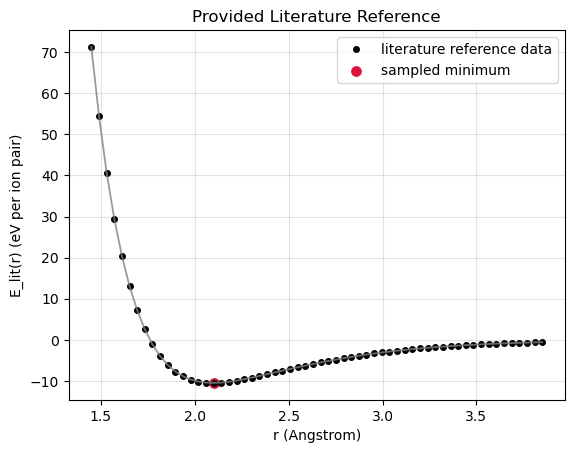

In [66]:
r_lit = r

# Literature reference Model
D_lit = 10.5
a_lit = 2.05
r0_lit_true = 2.10

E_lit_base = D_lit * (np.exp(-2*a_lit*(r_lit-r0_lit_true)) - 2*np.exp(-a_lit*(r_lit-r0_lit_true)))
E_lit = E_lit_base + 0.08*np.exp(-((r_lit-2.35)/0.20)**2)

idx_lit = np.argmin(E_lit)
r0_lit = r_lit[idx_lit]
U0_lit = E_lit[idx_lit]

print(f'Literature sampled minimum: r0={r0_lit:.5f}, U0={U0_lit:.5f}')

fig, ax = plt.subplots()
ax.plot(r_lit, E_lit, 'o', ms=4, color='black', label='literature reference data')
ax.plot(r_lit, E_lit, '-', lw=1.3, color='gray', alpha=0.8)
ax.scatter([r0_lit], [U0_lit], color='crimson', s=45, label='sampled minimum')
ax.set_xlabel('r (Angstrom)')
ax.set_ylabel('E_lit(r) (eV per ion pair)')
ax.set_title('Provided Literature Reference')
ax.legend()
ax.grid(True, alpha=0.35)
plt.show()

## Step 7 - Fit Lennard-Jones to reference

Now use the reference MgO energy curve from Step 6 as your target model.
Your task is to adjust the Lennard-Jones parameters $(\epsilon,\sigma)$ so that the Lennard-Jones potential matches this reference curve as well as possible.

### What you should do
1. Fit $(\epsilon,\sigma)$ which are the arguments passed to U_lj with <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html">curve_fit</a>. We have already defined The starting guess and bounds for the parameters.

> Note: curve_fit returns a tuple of two values however we are only interested in the first value that is returned. Since that value contains the fitted $(\epsilon,\sigma)$ which is again a tuple.

2. Compute the new equilibrium from $dU_{lj}/dr=0$.
3. Compute curvature $d^2U_{\mathrm{LJ}}/dr^2$ at that point.
4. Check $d^2U/dr^2>0$ at fitted equilibrium.
5. Compute the Root Mean Squared Error (RMSE) for fit quality check.

$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(U_{\mathrm{fit}}(r_i)-U_{\mathrm{ref}}(r_i)\right)^2}
$$

where $N$ is the number of sampled distance points, $U_{\mathrm{fit}}(r_i)$ is the fitted Lennard-Jones energy, and $U_{\mathrm{ref}}(r_i)$ is the reference energy at distance $r_i$.

**Hint:** You do not need to write the summation and normalization explicitly if you work with NumPy arrays.
For squared residuals, `np.mean(...)` already computes

In [67]:
# SETUP
p0_lj = [8.0, 1.9]
bounds_lj = ([0.1, 1.0], [80.0, 3.5])

In [69]:
# 1 TODO: Use curve_fit(U_lj, r_lit, E_lit, p0=p0_lj, bounds=bounds_lj) to get our fitted epsilon and sigma values.
popt_lj, pcov_lj = curve_fit(U_lj, r_lit, E_lit, p0=p0_lj, bounds=bounds_lj)
eps_lj_fit, sig_lj_fit = popt_lj

In [70]:
r0_lj_fit = brentq(dU_lj, 1.45, 3.85, args=(eps_lj_fit, sig_lj_fit))
U0_lj_fit = U_lj(r0_lj_fit, eps_lj_fit, sig_lj_fit)

In [71]:
curv_lj_fit = d2U_lj(r0_lj_fit, eps_lj_fit, sig_lj_fit)

In [ ]:
# 4 TODO: Again evaluate stability using the check_stable() function we have defined before.
# (again, already present in the cell below?)

In [72]:
assert check_stable(curv_lj_fit)

In [73]:
def rmse(y_ref, y_fit):
    return np.sqrt(np.mean((y_fit - y_ref) ** 2))

rmse_lj = rmse(E_lit, U_lj(r_lit, eps_lj_fit, sig_lj_fit))

In [74]:
print(f'LJ fit: eps={eps_lj_fit:.5f}, sigma={sig_lj_fit:.5f}')
print(f'LJ fit equilibrium: r0={r0_lj_fit:.5f}, U0={U0_lj_fit:.5f}, d2U={curv_lj_fit:.5f}')
print(f'LJ fit RMSE: {rmse_lj:.5f} eV')

LJ fit: eps=4.08611, sigma=1.72216
LJ fit equilibrium: r0=1.93306, U0=-4.08611, d2U=78.73231
LJ fit RMSE: 4.64748 eV


In [75]:
# Assert block 7
assert eps_lj_fit > 0 and sig_lj_fit > 0
assert 1.6 < r0_lj_fit < 2.8
assert curv_lj_fit > 0.0
assert rmse_lj < 13

## Step 8 - Fit Born-Landé to reference
Now do the same for the Born-Landé potential

### What you should do
1. Fit $(A,B,n)$ with <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html">curve_fit()</a>.
2. Compute equilibrium from $dU/dr=0$.
3. Check $d^2U/dr^2>0$ at fitted equilibrium.
4. Compute RMSE.

In [76]:
p0_bl = [85.0, 1200.0, 8.5]
bounds_bl = ([20.0, 10.0, 5.0], [220.0, 2.0e5, 14.0])

In [77]:
# 1 TODO: Fit A_bl, B_bl, n_bl for U_bl
popt_bl, pcov_bl = curve_fit(U_bl, r_lit, E_lit, p0=p0_bl, bounds=bounds_bl)
A_bl_fit, B_bl_fit, n_bl_fit = popt_bl

In [78]:
r0_bl_fit = brentq(dU_bl, 1.45, 3.85, args=(A_bl_fit, B_bl_fit, n_bl_fit))
U0_bl_fit = U_bl(r0_bl_fit, A_bl_fit, B_bl_fit, n_bl_fit)

In [79]:
curv_bl_fit = d2U_bl(r0_bl_fit, A_bl_fit, B_bl_fit, n_bl_fit)

In [80]:
rmse_bl = rmse(E_lit, U_bl(r_lit, A_bl_fit, B_bl_fit, n_bl_fit))

In [81]:
print(f'BL fit: A={A_bl_fit:.5f}, B={B_bl_fit:.5f}, n={n_bl_fit:.5f}')
print(f'BL fit equilibrium: r0={r0_bl_fit:.5f}, U0={U0_bl_fit:.5f}, d2U={curv_bl_fit:.5f}')
print(f'BL fit RMSE: {rmse_bl:.5f} eV')

BL fit: A=20.00000, B=3875.16779, n=10.16342
BL fit equilibrium: r0=2.28826, U0=-7.88029, d2U=15.29577
BL fit RMSE: 3.21002 eV


In [82]:
# Assert block 8
assert A_bl_fit > 0 and B_bl_fit > 0 and n_bl_fit > 0
assert 1.6 < r0_bl_fit < 2.8
assert curv_bl_fit > 0.0
assert rmse_bl < 13

## Step 9 - Final comparison: both fitted models vs literature (Optional)

### What you should do
1. Overlay literature data, fitted LJ, and fitted Born-Landé.
2. Compare $(r_0,U_0)$ for each model to literature minimum.
3. Compare curvature and RMSE side-by-side.


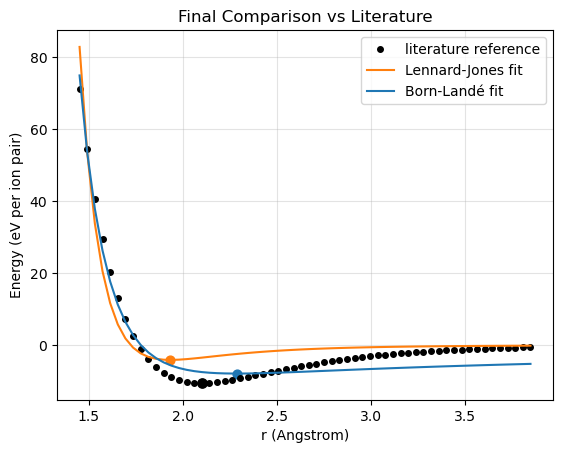

Model                  r0 [A]      U0 [eV]      d2U(r0)       RMSE
--------------------------------------------------------------------
Literature ref        2.10085    -10.48302            -          -
Lennard-Jones fit     1.93306     -4.08611     78.73231    4.64748
Born-Landé fit        2.28826     -7.88029     15.29577    3.21002

Absolute errors vs literature minimum:
  Lennard-Jones: |dr0|=0.16779, |dU0|=6.39692
  Born-Landé:    |dr0|=0.18741, |dU0|=2.60273


In [83]:
r_dense = r
E_lj_fit_dense = U_lj(r_dense, *popt_lj)
E_bl_fit_dense = U_bl(r_dense, *popt_bl)

fig, ax = plt.subplots()
ax.plot(r_lit, E_lit, 'o', ms=4, color='black', label='literature reference')
ax.plot(r_dense, E_lj_fit_dense, '-', color='tab:orange', label='Lennard-Jones fit')
ax.plot(r_dense, E_bl_fit_dense, '-', color='tab:blue', label='Born-Landé fit')
ax.scatter([r0_lit], [U0_lit], color='black', s=45)
ax.scatter([r0_lj_fit], [U0_lj_fit], color='tab:orange', s=40)
ax.scatter([r0_bl_fit], [U0_bl_fit], color='tab:blue', s=40)
ax.set_xlabel('r (Angstrom)')
ax.set_ylabel('Energy (eV per ion pair)')
ax.set_title('Final Comparison vs Literature')
ax.legend()
ax.grid(True, alpha=0.35)
plt.show()

err_r0_lj = abs(r0_lj_fit - r0_lit)
err_r0_bl = abs(r0_bl_fit - r0_lit)
err_U0_lj = abs(U0_lj_fit - U0_lit)
err_U0_bl = abs(U0_bl_fit - U0_lit)

print(f"{'Model':<18} {'r0 [A]':>10} {'U0 [eV]':>12} {'d2U(r0)':>12} {'RMSE':>10}")
print('-' * 68)
print(f"{'Literature ref':<18} {r0_lit:10.5f} {U0_lit:12.5f} {'-':>12} {'-':>10}")
print(f"{'Lennard-Jones fit':<18} {r0_lj_fit:10.5f} {U0_lj_fit:12.5f} {curv_lj_fit:12.5f} {rmse_lj:10.5f}")
print(f"{'Born-Landé fit':<18} {r0_bl_fit:10.5f} {U0_bl_fit:12.5f} {curv_bl_fit:12.5f} {rmse_bl:10.5f}")
print()
print('Absolute errors vs literature minimum:')
print(f"  Lennard-Jones: |dr0|={err_r0_lj:.5f}, |dU0|={err_U0_lj:.5f}")
print(f"  Born-Landé:    |dr0|={err_r0_bl:.5f}, |dU0|={err_U0_bl:.5f}")